In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from collections import Counter
import random
from sklearn.model_selection import train_test_split
import albumentations as A
from collections import defaultdict

DATA_ROOT = "/content/drive/MyDrive/DeepLearning_Project/data/train_images"
DATA_ROOT2 = "/content/drive/MyDrive/DeepLearning_Project/data/train_masks"

AUTHENTIC_DIR = Path(DATA_ROOT) / "authentic"
FORGED_DIR = Path(DATA_ROOT) / "forged"
MASK_DIR = Path(DATA_ROOT2)

label authentic 0 and forged 1

In [9]:
np.random.seed(42)

# Get all image paths
authentic_images = sorted(list(AUTHENTIC_DIR.glob('*.png')) +
                         list(AUTHENTIC_DIR.glob('*.jpg')))
forged_images = sorted(list(FORGED_DIR.glob('*.png')) +
                      list(FORGED_DIR.glob('*.jpg')))

# Create labels (0 = authentic, 1 = forged)
authentic_labels = [0] * len(authentic_images)
forged_labels = [1] * len(forged_images)

# Create mask paths (None for authentic, actual path for forged)
authentic_masks = [None] * len(authentic_images)
forged_masks = []

for img_path in forged_images:
    mask_path = MASK_DIR / f"{img_path.stem}.npy"
    if mask_path.exists():
        forged_masks.append(mask_path)
    else:
        forged_masks.append(None)

# Combine all data
all_images = authentic_images + forged_images
all_masks = authentic_masks + forged_masks
all_labels = authentic_labels + forged_labels

CREATE TRAIN/VAL SPLIT

In [10]:
def list_images_in_dir(directory, extensions=('.png', '.jpg', '.jpeg')):
    """List all image files in directory with given extensions."""
    return sorted([
        file for ext in extensions
        for file in Path(directory).glob(f"*{ext}")])

# Load image paths and labels
authentic_images = list_images_in_dir(AUTHENTIC_DIR)
forged_images = list_images_in_dir(FORGED_DIR)

images = authentic_images + forged_images
labels = [0] * len(authentic_images) + [1] * len(forged_images)
masks = [all_masks[i] for i in range(len(images))] if 'all_masks' in locals() else []

# Create train/val/test splits with stratification
# First: Split 90% (train+val) and 10% test
train_val_idx, test_idx = train_test_split(
    range(len(images)),
    test_size=0.1,
    random_state=42,
    stratify=labels)

# Second: Split train_val into 70% train and 20% val (of original)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.2222,  # 20% of original / 90% remaining = 0.2222
    random_state=42,
    stratify=[labels[i] for i in train_val_idx])

# Create data subsets
def create_subset(indices):
    """Create subset of data for given indices."""
    return {
        'images': [images[i] for i in indices],
        'labels': [labels[i] for i in indices],
        'masks': [masks[i] for i in indices] if masks else []
    }

train_data = create_subset(train_idx)
val_data = create_subset(val_idx)
test_data = create_subset(test_idx)

# Save splits to CSV
def save_to_csv(data, filepath):
    """Save data split to CSV file."""
    df = pd.DataFrame({
        'path': [str(p) for p in data['images']],
        'label': ['authentic' if label == 0 else 'forged' for label in data['labels']]
    })
    df.to_csv(filepath, index=False)
    return filepath

output_dir = Path("/content/drive/MyDrive/DeepLearning_Project/splits")
output_dir.mkdir(parents=True, exist_ok=True)

# Save all splits
splits = {
    'train': (train_data, output_dir / "train_split.csv"),
    'val': (val_data, output_dir / "val_split.csv"),
    'test': (test_data, output_dir / "test_split.csv")
}

print("\nSaved split files:")
for split_name, (data, filepath) in splits.items():
    save_to_csv(data, filepath)
    print(f"  {filepath}")


Saved split files:
  /content/drive/MyDrive/DeepLearning_Project/splits/train_split.csv
  /content/drive/MyDrive/DeepLearning_Project/splits/val_split.csv
  /content/drive/MyDrive/DeepLearning_Project/splits/test_split.csv


Loaded sample: 53404.png
  Image shape: (666, 1000, 3)
  Mask shape: (666, 1000)
  Mask values: [0. 1.]


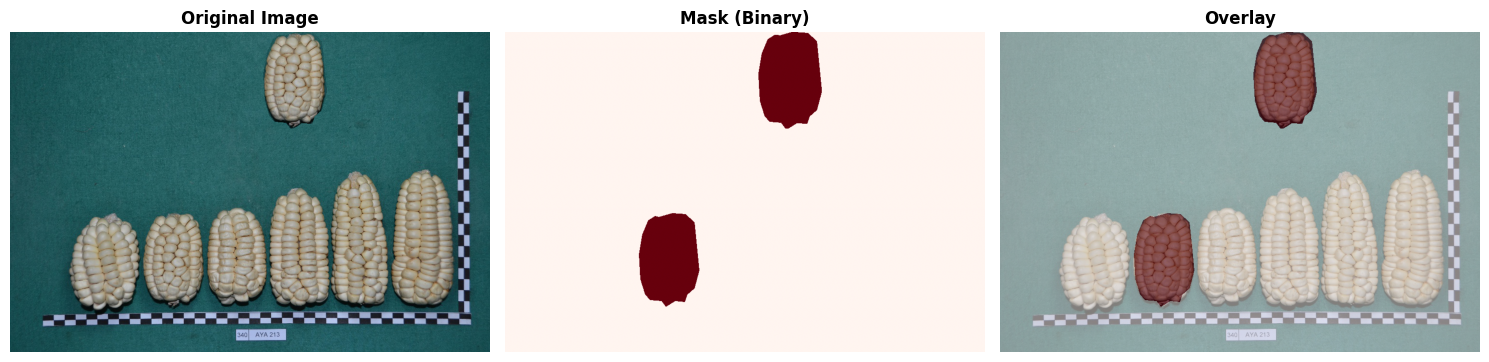

In [12]:
# load sample image from the train
def load_sample(image_path, mask_path, label):
    """Load one image and its mask."""
    # Load image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load mask
    if label == 1 and mask_path is not None:
        mask_array = np.load(mask_path)
        # Collapse instances to single binary mask
        mask = mask_array.max(axis=0).astype(np.float32)
    else:
        # Authentic image - empty mask
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)

    return image, mask

# Load one sample from training set
sample_idx = next(i for i, label in enumerate(train_data['labels']) if label == 1)  # Get a forged sample
sample_image, sample_mask = load_sample(
    train_data['images'][sample_idx],
    train_data['masks'][sample_idx],
    train_data['labels'][sample_idx]
)

print(f"Loaded sample: {train_data['images'][sample_idx].name}")
print(f"  Image shape: {sample_image.shape}")
print(f"  Mask shape: {sample_mask.shape}")
print(f"  Mask values: {np.unique(sample_mask)}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample_image)
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(sample_mask, cmap='Reds')
axes[1].set_title('Mask (Binary)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(sample_image)
axes[2].imshow(sample_mask, alpha=0.5, cmap='Reds')
axes[2].set_title('Overlay', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Image Resize

In [13]:
TARGET_SIZE = (512, 512)  # (height, width)

# ImageNet normalization values
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

print(f"Target image size: {TARGET_SIZE}")
print(f"Normalization: Mean={MEAN}, Std={STD}")

Target image size: (512, 512)
Normalization: Mean=[0.485, 0.456, 0.406], Std=[0.229, 0.224, 0.225]


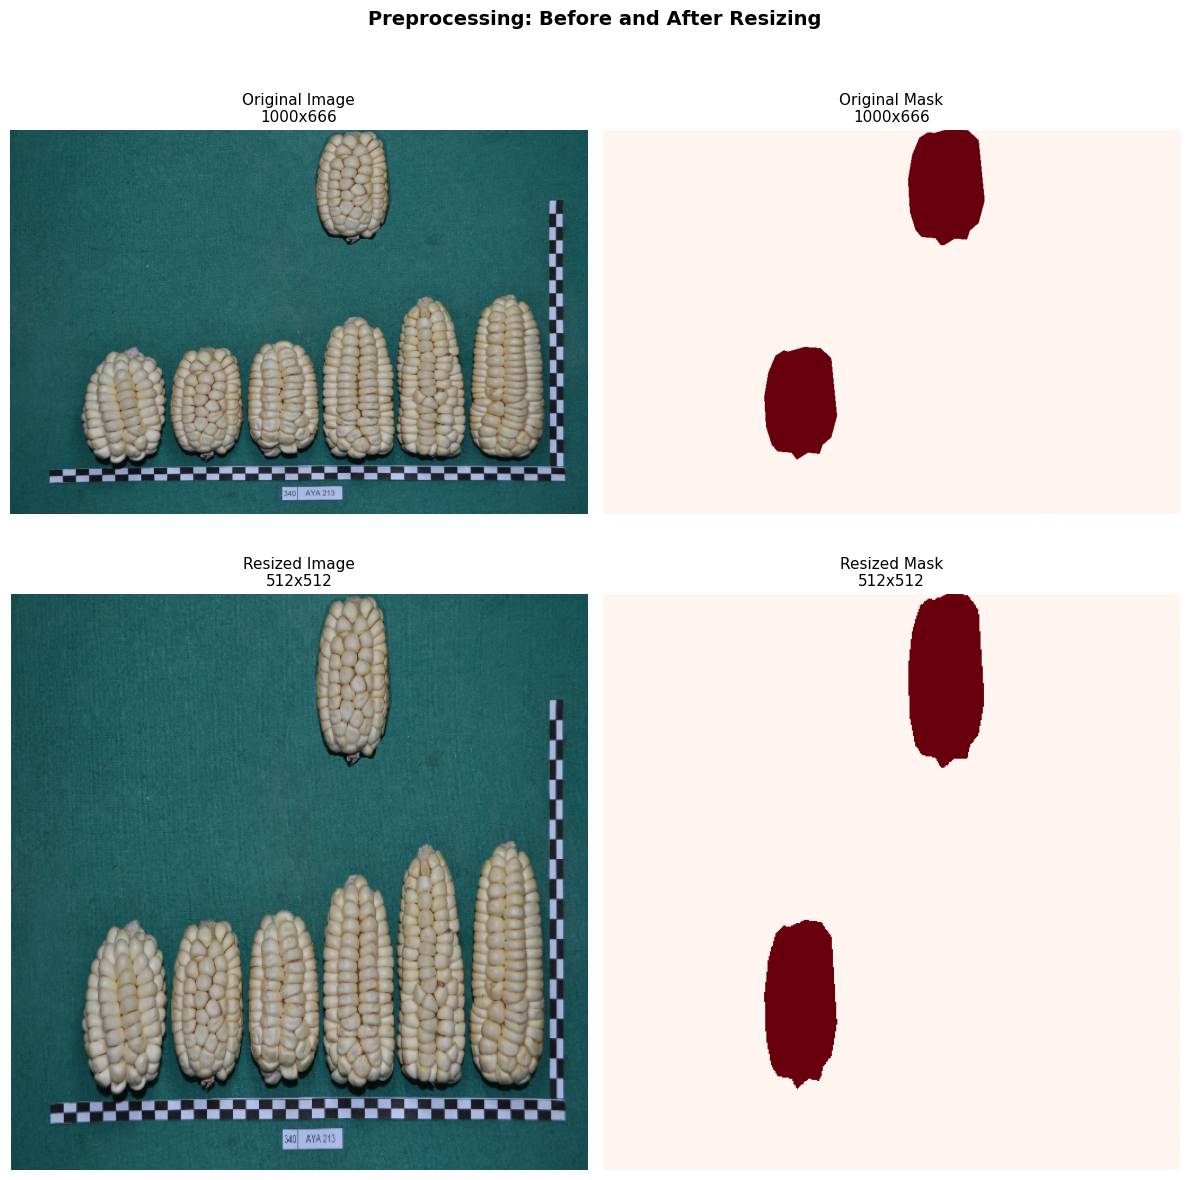

In [14]:
# Simple preprocessing (resize only)
def preprocess_simple(image, mask, target_size=TARGET_SIZE):
    """Resize image and mask to target size."""
    h, w = target_size

    # Resize image
    image_resized = cv2.resize(image, (w, h), interpolation=cv2.INTER_LINEAR)

    # Resize mask
    mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

    return image_resized, mask_resized

# Test preprocessing
image_preprocessed, mask_preprocessed = preprocess_simple(sample_image, sample_mask)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(sample_image)
axes[0, 0].set_title(f'Original Image\n{sample_image.shape[1]}x{sample_image.shape[0]}', fontsize=11)
axes[0, 0].axis('off')

axes[0, 1].imshow(sample_mask, cmap='Reds')
axes[0, 1].set_title(f'Original Mask\n{sample_mask.shape[1]}x{sample_mask.shape[0]}', fontsize=11)
axes[0, 1].axis('off')

axes[1, 0].imshow(image_preprocessed)
axes[1, 0].set_title(f'Resized Image\n{image_preprocessed.shape[1]}x{image_preprocessed.shape[0]}', fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(mask_preprocessed, cmap='Reds')
axes[1, 1].set_title(f'Resized Mask\n{mask_preprocessed.shape[1]}x{mask_preprocessed.shape[0]}', fontsize=11)
axes[1, 1].axis('off')

plt.suptitle('Preprocessing: Before and After Resizing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Checks

In [16]:
#  Do authentic images have no masks
authentic_with_masks = sum(1 for label, mask in zip(train_data['labels'], train_data['masks'])
                          if label == 0 and mask is not None)
if authentic_with_masks > 0:
    print(f" Warning: {authentic_with_masks} authentic images have masks")
else:
    print(" Authentic images correctly have no masks")

 Authentic images correctly have no masks


In [20]:
# Save to Google Drive so you can reuse the same split later
split_save_path = Path("/content/drive/MyDrive/DeepLearning_Project/train_val_split.npz")
split_save_path.parent.mkdir(parents=True, exist_ok=True)

np.savez(
    split_save_path,
    train_idx=train_idx,
    val_idx=val_idx,
    seed=42
)